<a href="https://colab.research.google.com/github/mmacrides/DREAMT_FE/blob/master/experiments_collab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/mmacrides/DREAMT_FE.git
import os
os.chdir("DREAMT_FE")  # Change directory to the cloned repo

Cloning into 'DREAMT_FE'...
remote: Enumerating objects: 289, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 289 (delta 36), reused 25 (delta 9), pack-reused 218 (from 1)
Receiving objects: 100% (289/289), 99.92 MiB | 5.58 MiB/s, done.
Resolving deltas: 100% (36/36), done.
Updating files: 100% (217/217), done.


In [2]:
!pip install -q condacolab
!pip install gpboost
import condacolab
condacolab.install()
!conda --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.5 MB/s eta 0:00:00
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...
conda 24.11.2


In [1]:
#creating the environment
!conda env create -f environment.yml

Channels:
 - conda-forge
Platform: linux-64
Solving environment: / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 25.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/env





Preparing transaction: - done
Verifying transaction: | / done
Executing transaction: \ done
#
# To activate this environment, use
#
#     $ conda activate env
#
# To deactivate an active environment, use
#
#     $ conda deactivate


CondaError: Run 'conda init' before 'conda activate'



In [2]:
!conda activate env


CondaError: Run 'conda init' before 'conda activate'



In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
import pandas as pd
import numpy as np
import random
import warnings
from utils import *
from datasets import *
from models import *

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Set display options
pd.set_option("display.max_rows", 500)  # Replace 500 with your desired number of rows
pd.set_option(
    "display.max_columns", 10
)  # Replace 10 with your desired number of columns
pd.set_option("display.width", 1000)  # Adjust the width as needed
pd.set_option("display.max_colwidth", 50)  # Adjust the column width as needed

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
# Prepare the data
# Adjust your path here
quality_df_dir = './results/quality_scores_per_subject.csv'
features_dir = "dataset_sample/features_df/"
info_dir = "dataset_sample/participant_info.csv"
clean_df, new_features, good_quality_sids = data_preparation(
    threshold = 0.2,
    quality_df_dir = quality_df_dir,
    features_dir = features_dir,
    info_dir = info_dir)
print(clean_df.shape)
print(len(new_features))

/content/DREAMT_FE/datasets.py:75: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  path = str(features_dir) + str(info_df.SID[0]) + '_domain_features_df.csv'
/content/DREAMT_FE/datasets.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_subjects_fe_df = pd.concat([all_subjects_fe_df, sid_df], ignore_index=True)
/content/DREAMT_FE/datasets.py:184: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future 

(82671, 610)
597


### Split data to train, val, and test

In [ ]:
SW_df, final_features = split_data(clean_df, good_quality_sids, new_features)
SW_df

,PPG_Rate_Mean,HRV_SDNN,HRV_MadNN,HRV_SDRMSSD,HRV_Prc20NN,...,Hypopnea,Multiple_Events,artifact,sid,BMI
1,87.451445,267.856258,277.987500,0.762788,468.750,...,0.0,0.0,0,S003,51.0
2,84.687304,280.299933,231.656250,0.672688,515.625,...,0.0,0.0,1,S003,51.0
3,90.889185,224.392912,208.490625,0.730625,465.625,...,0.0,0.0,1,S003,51.0
4,79.140186,303.274460,324.318750,0.769270,468.750,...,0.0,0.0,1,S003,51.0
5,90.383327,297.089740,289.570312,0.767894,450.000,...,0.0,0.0,1,S003,51.0
...,...,...,...,...,...,...,...,...,...,...,...
85066,61.392727,132.432765,23.165625,0.856175,1000.000,...,0.0,0.0,0,S102,26.0
85067,61.198295,138.500822,46.331250,1.081764,978.125,...,0.0,0.0,0,S102,26.0
85068,57.181574,18.233936,23.165625,0.781327,1031.250,...,0.0,0.0,0,S102,26.0
85069,57.535505,17.652470,23.165625,0.934502,1031.250,...,0.0,0.0,0,S102,26.0


In [ ]:
import random
random.seed(0)
train_sids = random.sample(good_quality_sids, 56)
remaining_sids = [subj for subj in good_quality_sids if subj not in train_sids]
val_sids = random.sample(remaining_sids, 8)
test_sids = [subj for subj in remaining_sids if subj not in val_sids]

group_variables = ['AHI_Severity', 'Obesity']
# when idx == 0, it returns ['AHI_Severity'], the first variable in the list
# when idx == 1, it returns ['Obesity'], the second variable in the list
group_variable = get_variable(group_variables, idx = 0) # set your variable

In [ ]:
X_train, y_train, group_train = train_test_split(SW_df, train_sids, final_features, group_variable)
print("Train data balance: ")
print(np.unique(y_train, return_counts=True))
print('')

X_val, y_val, group_val = train_test_split(SW_df, val_sids, final_features, group_variable)
print("Validation data balancpredicted_probabilitiese: ")
print(np.unique(y_val, return_counts=True))
print('')

X_test, y_test, group_test = train_test_split(SW_df, test_sids, final_features, group_variable)
print("Test data balance: ")
print(np.unique(y_test, return_counts=True))
print(y_train.sum())

Train data balance: 
(array([0., 1.]), array([33063, 24620]))

Validation data balancpredicted_probabilitiese: 
(array([0., 1.]), array([5001, 3038]))

Test data balance: 
(array([0., 1.]), array([10402,  6547]))
24620.0


### Resample data

In [ ]:
X_train_resampled, y_train_resampled, group_train_resampled = resample_data(X_train, y_train, group_train, group_variable)

### LightGBM

In [ ]:
final_lgb_model = LightGBM_engine(X_train_resampled, y_train_resampled, X_val, y_val)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



  2%|▏         | 1/50 [00:23<19:19, 23.65s/trial, best loss: -0.6857224935363402]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



  4%|▍         | 2/50 [00:43<16:58, 21.21s/trial, best loss: -0.6857224935363402]

...

 98%|█████████▊| 49/50 [19:54<00:19, 19.40s/trial, best loss: -0.698615865456169]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



100%|██████████| 50/50 [20:22<00:00, 24.45s/trial, best loss: -0.698615865456169]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/lightgbm/engine.py:204: UserWarning: Found `num_iterations` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")



Best hyperparameters: {'learning_rate': 0.17326956982047004, 'max_depth': 5.0, 'n_estimators': 260.0, 'num_leaves': 100.0, 'reg_alpha': 106.0, 'reg_lambda': 1.949938610043549}


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[[30038  3025]
 [ 3600 21020]]


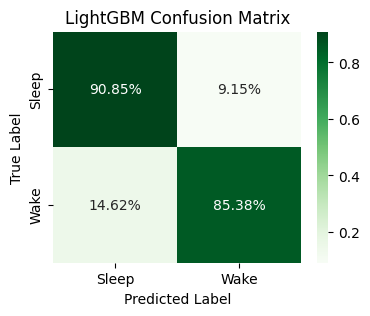

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

[[8926 1476]
 [ 913 5634]]


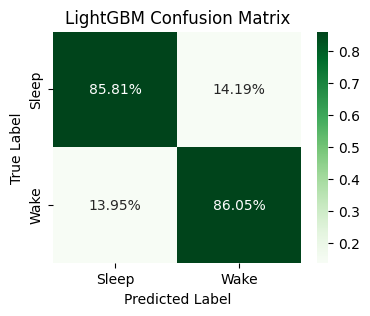

,Model,Precision,Recall,F1 Score,Specificity,AUROC,AUPRC,Accuracy,Cohen's Kappa
0,LightGBM,0.792405,0.860547,0.825071,0.858104,0.931559,0.91483,0.859048,0.699206


In [ ]:
# calculate training scores
prob_ls_train, len_train, true_ls_train = compute_probabilities(
    train_sids, SW_df, final_features, "lgb", final_lgb_model, group_variable)
lgb_train_results_df = LightGBM_result(final_lgb_model, X_train, y_train, prob_ls_train, true_ls_train)

# # calculate testing scores
prob_ls_test, len_test, true_ls_test = compute_probabilities(
    test_sids, SW_df, final_features, "lgb", final_lgb_model, group_variable)
lgb_test_results_df = LightGBM_result(final_lgb_model, X_test, y_test, prob_ls_test, true_ls_test)
lgb_test_results_df


/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


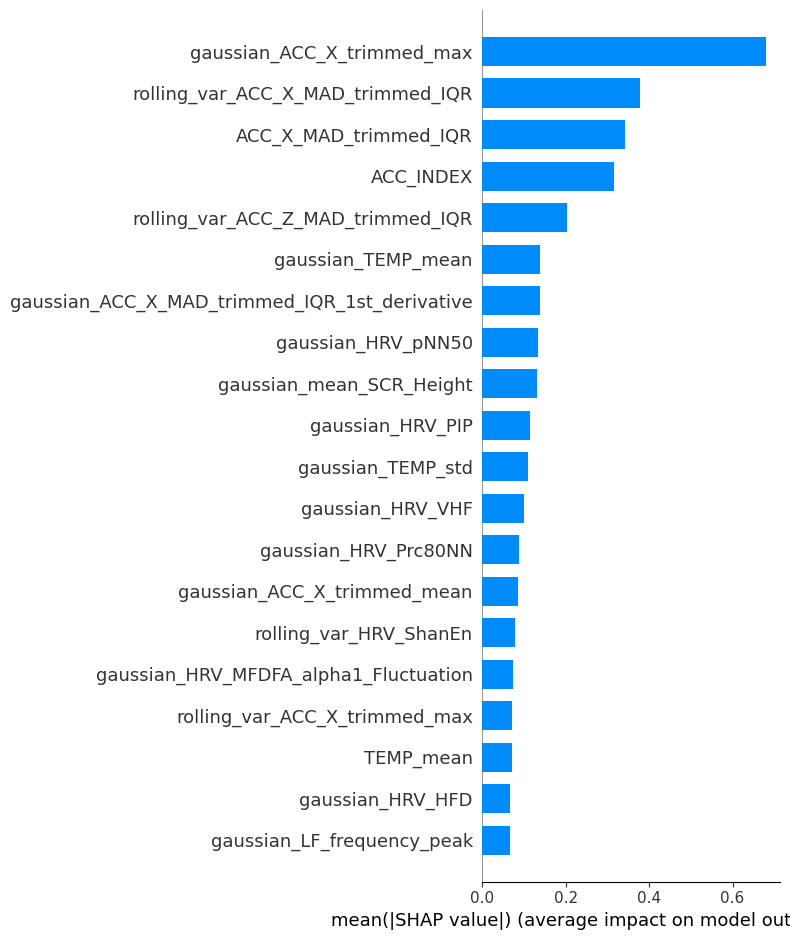

In [ ]:
import shap
explainer = shap.TreeExplainer(final_lgb_model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train, plot_type="bar", feature_names=final_features)